In [2]:
global colorsNw
colorsNw = {
    "gray": {
        0: "#f8f9fa",
        1: "#f1f3f5",
        2: "#e9ecef",
        3: "#dee2e6",
        4: "#ced4da",
        5: "#adb5bd",
        6: "#868e96",
        7: "#495057",
        8: "#343a40",
        9: "#212529",
    },
    "red": {
        0: "#fff5f5",
        1: "#ffe3e3",
        2: "#ffc9c9",
        3: "#ffa8a8",
        4: "#ff8787",
        5: "#ff6b6b",
        6: "#fa5252",
        7: "#f03e3e",
        8: "#e03131",
        9: "#c92a2a",
    },
    "pink": {
        0: "#fff0f6",
        1: "#ffdeeb",
        2: "#fcc2d7",
        3: "#faa2c1",
        4: "#f783ac",
        5: "#f06595",
        6: "#e64980",
        7: "#d6336c",
        8: "#c2255c",
        9: "#a61e4d",
    },
    "grape": {
        0: "#f8f0fc",
        1: "#f3d9fa",
        2: "#eebefa",
        3: "#e599f7",
        4: "#da77f2",
        5: "#cc5de8",
        6: "#be4bdb",
        7: "#ae3ec9",
        8: "#9c36b5",
        9: "#862e9c",
    },
    "violet": {
        0: "#f3f0ff",
        1: "#e5dbff",
        2: "#d0bfff",
        3: "#b197fc",
        4: "#9775fa",
        5: "#845ef7",
        6: "#7950f2",
        7: "#7048e8",
        8: "#6741d9",
        9: "#5f3dc4",
    },
    "indigo": {
        0: "#edf2ff",
        1: "#dbe4ff",
        2: "#bac8ff",
        3: "#91a7ff",
        4: "#748ffc",
        5: "#5c7cfa",
        6: "#4c6ef5",
        7: "#4263eb",
        8: "#3b5bdb",
        9: "#364fc7",
    },
    "blue": {
        0: "#e7f5ff",
        1: "#d0ebff",
        2: "#a5d8ff",
        3: "#74c0fc",
        4: "#4dabf7",
        5: "#339af0",
        6: "#228be6",
        7: "#1c7ed6",
        8: "#1971c2",
        9: "#1864ab",
    },
    "cyan": {
        0: "#e3fafc",
        1: "#c5f6fa",
        2: "#99e9f2",
        3: "#66d9e8",
        4: "#3bc9db",
        5: "#22b8cf",
        6: "#15aabf",
        7: "#1098ad",
        8: "#0c8599",
        9: "#0b7285",
    },
    "teal": {
        0: "#e6fcf5",
        1: "#c3fae8",
        2: "#96f2d7",
        3: "#63e6be",
        4: "#38d9a9",
        5: "#20c997",
        6: "#12b886",
        7: "#0ca678",
        8: "#099268",
        9: "#087f5b",
    },
    "green": {
        0: "#ebfbee",
        1: "#d3f9d8",
        2: "#b2f2bb",
        3: "#8ce99a",
        4: "#69db7c",
        5: "#51cf66",
        6: "#40c057",
        7: "#37b24d",
        8: "#2f9e44",
        9: "#2b8a3e",
    },
    "lime": {
        0: "#f4fce3",
        1: "#e9fac8",
        2: "#d8f5a2",
        3: "#c0eb75",
        4: "#a9e34b",
        5: "#94d82d",
        6: "#82c91e",
        7: "#74b816",
        8: "#66a80f",
        9: "#5c940d",
    },
    "yellow": {
        0: "#fff9db",
        1: "#fff3bf",
        2: "#ffec99",
        3: "#ffe066",
        4: "#ffd43b",
        5: "#fcc419",
        6: "#fab005",
        7: "#f59f00",
        8: "#f08c00",
        9: "#e67700",
    },
    "orange": {
        0: "#fff4e6",
        1: "#ffe8cc",
        2: "#ffd8a8",
        3: "#ffc078",
        4: "#ffa94d",
        5: "#ff922b",
        6: "#fd7e14",
        7: "#f76707",
        8: "#e8590c",
        9: "#d9480f",
    },
    "mixed": {
        0: "#880e4f",
        1: "#1a237e",
        2: "#e65100",
        3: "#004d40",
        4: "#c92a2a",
    },
}

In [3]:
import sys
sys.path.append("/home/vishnu/git-test/lama")

In [4]:
from pathlib import Path
model_path = Path("/home/vishnu/git-test/lama/big-lama")

In [6]:
import torch
import cv2
import kornia
import saicinpainting

In [8]:
import os
import cv2
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib as mpl
from PIL import Image

import pandas as pd

from omegaconf import OmegaConf
# from torch.utils.data import default_collate
from torch.utils.data._utils.collate import default_collate

from saicinpainting.evaluation.data import scale_image, pad_img_to_modulo
from saicinpainting.evaluation.utils import move_to_device
from saicinpainting.training.trainers import load_checkpoint

### Prediction function

In [9]:
@torch.no_grad()
def predict(model_path, img, mask, pad_out_to_modulo=8, scale_factor=None):

    img = img.astype(np.float32)

    img_min = img.min()
    img_max = img.max()
    img = (img - img_min) / (img_max - img_min)

    device = torch.device("cpu")

    with open(model_path / "config.yaml") as f:
        train_config = OmegaConf.create(yaml.safe_load(f))

    train_config.training_model.predict_only = True
    train_config.visualizer.kind = "noop"

    # train_config.training_model.device = "cpu"
    checkpoint_path = model_path / "models" / "best.ckpt"
    model = load_checkpoint(train_config, checkpoint_path, strict=False, map_location="cpu")
    model.freeze()

    dset = {
        "image": np.transpose(img, (2,0,1)),
        "mask": mask[None, ...],
    }

    if scale_factor is not None:
        dset["image"] = scale_image(dset["image"], scale_factor)
        dset["mask"] = scale_image(
            dset["mask"], scale_factor,
            interpolation=cv2.INTER_NEAREST
        )

    if pad_out_to_modulo:
        dset["unpad_to_size"] = dset["image"].shape[1:]
        dset["image"] = pad_img_to_modulo(dset["image"], pad_out_to_modulo)
        dset["mask"] = pad_img_to_modulo(dset["mask"], pad_out_to_modulo)

    batch = default_collate([dset])
    batch = move_to_device(batch, device)

    batch = model(batch)
    cur_res = batch["inpainted"].cpu().numpy()[0]

    if "unpad_to_size" in batch:
        h, w = batch["unpad_to_size"]
        cur_res = cur_res[:, :h, :w]

    cur_res = np.transpose(cur_res, (1,2,0))
    cur_res = (img_max - img_min) * cur_res + img_min

    return cur_res

# Test images + mask

In [66]:
# def get_img_1(size):
#     x = np.linspace(0,2*np.pi,size[0], endpoint=False)[:,None]
#     y = np.linspace(0,2*np.pi,size[1], endpoint=False)[None,:]

#     img = np.stack([
#         np.sin(x)*np.cos(3*y),
#         np.sin(4*(x+y)),
#         np.cos(np.sqrt(x**2 + y**2)),
#     ], axis=-1).astype(np.float32)

#     img -= img.min()
#     img /= img.max()
#     return img

def get_img_1(size, L_ref=128):
    Lx, Ly, _ = size

    x = np.linspace(0, 2*np.pi, Lx, endpoint=False)[:, None]
    y = np.linspace(0, 2*np.pi, Ly, endpoint=False)[None, :]

    # scaling factor
    s = Lx / L_ref

    img = np.stack([
        np.sin(s * x) * np.cos(3 * s * y),
        np.sin(4 * s * (x + y)),
        np.cos(s * np.sqrt(x**2 + y**2)),
    ], axis=-1).astype(np.float32)

    img -= img.min()
    img /= img.max()

    return img

def get_img_grid(size, step=16, thickness=2):
    h, w, c = size
    img = np.zeros(size, dtype=np.float32)
    
    # Create a grid mask
    y, x = np.mgrid[:h, :w]
    grid_mask = ((x % step) < thickness) | ((y % step) < thickness)
    
    # Fill grid with white, background with dark gradient
    # Channel 0: Horizontal variation
    img[..., 0] = x / w 
    # Channel 1: Vertical variation
    img[..., 1] = y / h
    # Channel 2: The Grid itself
    img[..., 2] = grid_mask.astype(np.float32)
    
    # Apply grid to all channels for high contrast structure
    img[grid_mask] = 1.0
    
    return img

def get_img_checkerboard(size, square_size=16):
    h, w, c = size
    y, x = np.mgrid[:h, :w]
    
    # Basic checkerboard pattern (0 or 1)
    # The (x // size) creates steps, sum checks parity
    checkers = ((x // square_size) + (y // square_size)) % 2
    
    img = np.zeros(size, dtype=np.float32)
    
    # Channel 0: The raw checkers (Black/White)
    img[..., 0] = checkers
    
    # Channel 1: Checkers modulated by a sine wave (Varying intensity)
    img[..., 1] = checkers * (0.5 + 0.5 * np.sin(x / 10))
    
    # Channel 2: Inverted checkers
    img[..., 2] = 1 - checkers
    
    return img

def get_img_shapes(size):
    h, w, c = size
    y, x = np.mgrid[:h, :w]
    img = np.zeros(size, dtype=np.float32)
    
    # 1. A large Circle (tests curvature continuity)
    center_x, center_y = w // 2, h // 2
    radius = min(h, w) // 4
    mask_circle = (x - center_x)**2 + (y - center_y)**2 < radius**2
    
    # 2. A Triangle/Diagonal (tests diagonal edge reconstruction - aliasing prone)
    mask_tri = (x + y) < (w + h) // 2
    
    # Channel 0: Circle on background
    img[..., 0] = mask_circle.astype(float)
    
    # Channel 1: Triangle intersection
    img[..., 1] = np.logical_xor(mask_circle, mask_tri).astype(float)
    
    # Channel 2: Smooth background + Hard Shape overlay
    background = np.sin(x/10) * np.cos(y/10)
    img[..., 2] = np.where(mask_circle, 1.0, (background - background.min())/(background.max() - background.min()))
    
    return img

def get_img_smooth(size):
    H, W, _ = size

    x = np.linspace(0, 2*np.pi, H, endpoint=False)[:, None]
    y = np.linspace(0, 2*np.pi, W, endpoint=False)[None, :]

    X = np.broadcast_to(x, (H, W))
    Y = np.broadcast_to(y, (H, W))

    img = np.stack([
        np.sin(X),
        np.cos(Y),
        np.sin(X + Y)
    ], axis=-1).astype(np.float32)

    img -= img.min()
    img /= img.max()
    return img

def get_img_edges(size):
    img = np.zeros(size, dtype=np.float32)

    H, W, _ = size

    img[:H//2, :, 0] = 1.0
    img[:, :W//3, 1] = 1.0
    img[H//3:2*H//3, W//3:2*W//3, 2] = 1.0

    return img

def get_img_noise(size, seed=0):
    rng = np.random.default_rng(seed)
    img = rng.normal(0, 1, size).astype(np.float32)

    img -= img.min()
    img /= img.max()
    return img

def get_mask_1(size):
    ix = np.arange(size[0])
    iy = np.arange(size[1])
    return ((ix[:,None] < size[0]//2) &
            (iy[None,:] < size[1]//2)).astype(np.uint8)

def get_mask_shifted(size, x0, y0, wx, wy):
    mask = np.zeros(size[:2], dtype=np.uint8)
    mask[x0:x0+wx, y0:y0+wy] = 1
    return mask


## Natural images

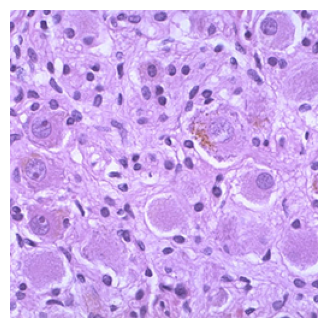

In [64]:
# Load image
img = Image.open("nat01.png").convert("RGB")

# Original size
W, H = img.size   # W=504, H=331

# Center crop to square (331×331)
crop_size = min(W, H)

left = (W - crop_size) // 2
top = (H - crop_size) // 2

img_cropped = img.crop((left, top, left + crop_size, top + crop_size))

# Resize to 128×128 using high-quality downsampling
nat01_128 = img_cropped.resize((256, 256), Image.Resampling.LANCZOS)
nat01_128.save("nat01_64.png")

# Convert to numpy array if needed
# img_array = np.array(img_128)

# visualize
plt.figure(figsize=(4,4))
plt.imshow(nat01_128)
plt.axis("off")
plt.show()

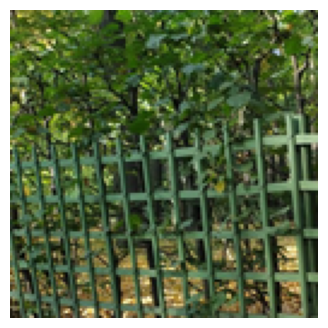

In [60]:
# Load RGB image
img = Image.open("nat02.png").convert("RGB")

# Original size
W, H = img.size   # 1200 × 900

# Center crop to square
crop_size = 400 # min(W, H)

# left = (W - crop_size) // 2    # 150
# top = (H - crop_size) // 2     # 0

# Top-left crop (keep left-top corner fixed)
img_cropped = img.crop((0, 0, crop_size, crop_size))

# img_cropped = img.crop((left, top, left + crop_size, top + crop_size))

# Resize to 128×128 using high-quality filter
nat02_128 = img_cropped.resize((128,128), Image.Resampling.LANCZOS)
nat02_128.save("nat02_256.png")

# Convert to numpy array
# img_array = np.array(img_128)

# visualize
plt.figure(figsize=(4,4))
plt.imshow(nat02_128)
plt.axis("off")
plt.show()

In [11]:
%matplotlib inline

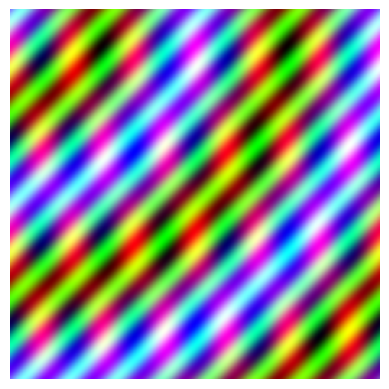

In [72]:
size = (256,256,3)
img1 = get_img_1(size)
plt.imshow(img1)
plt.axis("off")
plt.show()

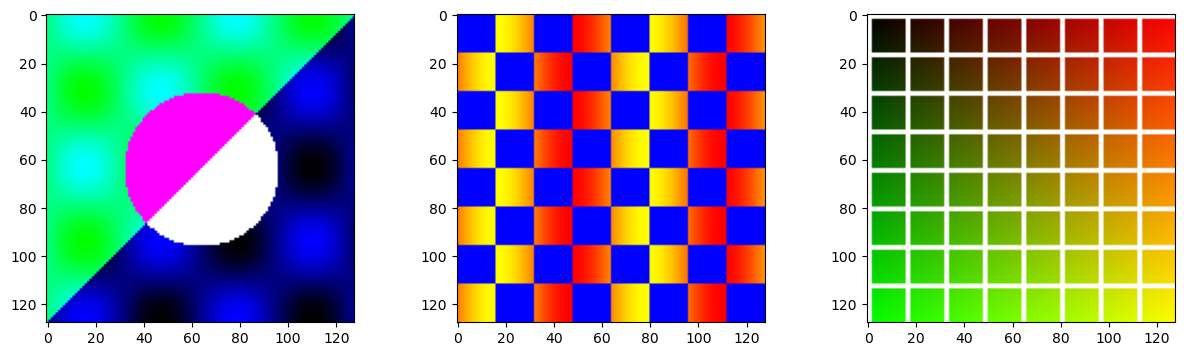

In [15]:
size = (128,128,3)
img1 = get_img_shapes(size)
img2 = get_img_checkerboard(size)
img3 = get_img_grid(size)

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.imshow(img1)

plt.subplot(1,3,2)
plt.imshow(img2)

plt.subplot(1,3,3)
plt.imshow(img3)

plt.show()

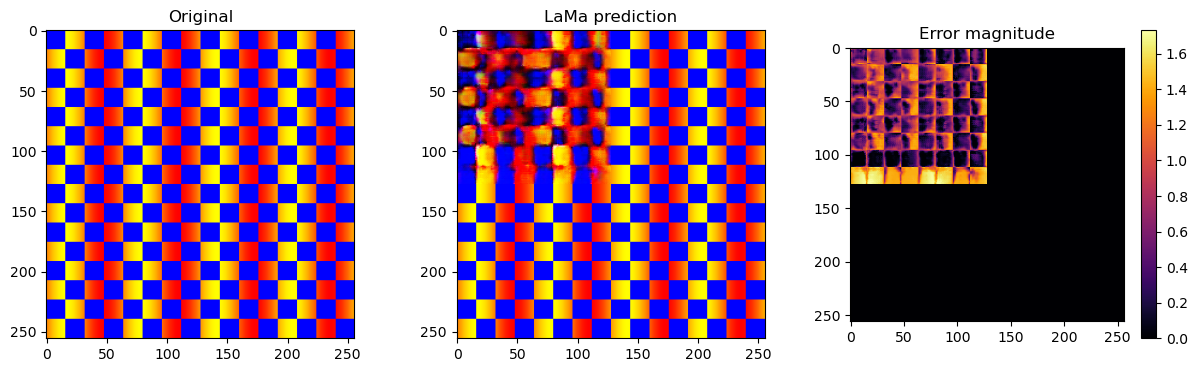

In [75]:
size = (256,256,3)

img = get_img_checkerboard(size)
# img = get_img_1(size)

# img = Image.open("nat02_64.png").convert("RGB")
# img = np.array(img).astype(np.float32) / 255.0 

mask = get_mask_1(size)

model_path = Path("/home/vishnu/git-test/lama/big-lama")

pred = predict(model_path, img, mask)

err = pred - img

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(pred)
plt.title("LaMa prediction")

plt.subplot(1,3,3)
plt.imshow(np.linalg.norm(err, axis=-1), cmap="inferno")
plt.title("Error magnitude")
plt.colorbar()

plt.show()

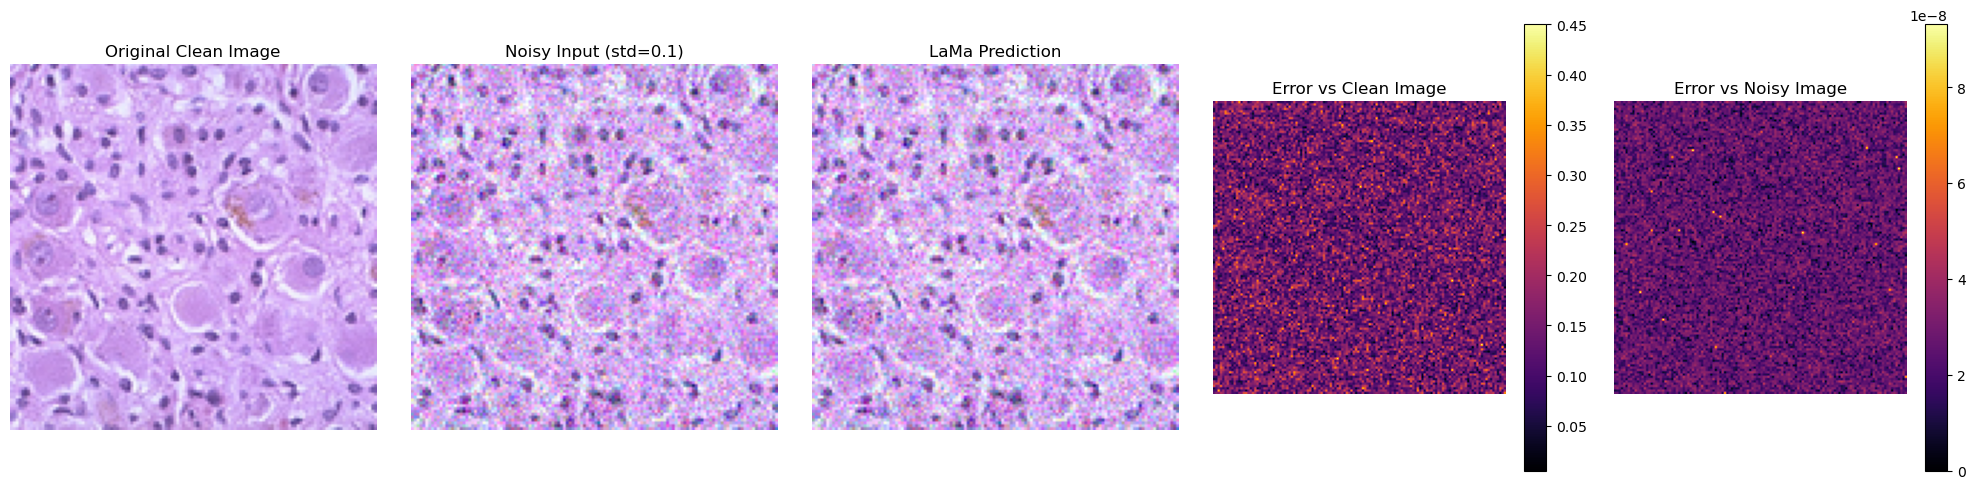

In [17]:
size = (128, 128, 3)

img = Image.open("nat01_128.png").convert("RGB")
img = np.array(img).astype(np.float32) / 255.0 
# img = get_img_1(size)

# Generate and add White Gaussian Noise
noise_std = 0.1
white_noise = np.random.normal(loc=0.0, scale=noise_std, size=img.shape)

# Add noise and clip values to maintain a valid [0, 1] image range
noisy_img = np.clip(img + white_noise, 0.0, 1.0)

# Create an EMPTY mask 
# LaMa still requires the mask array to be passed to the forward function
empty_mask = np.zeros((size[0], size[1]), dtype=np.float32)

model_path = Path("/home/vishnu/git-test/lama/big-lama")

pred = predict(model_path, noisy_img, empty_mask)

err = pred - img

err2 = pred - noisy_img

# Plots 
plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("Original Clean Image")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(noisy_img)
plt.title(f"Noisy Input (std={noise_std})")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(pred)
plt.title("LaMa Prediction")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(np.linalg.norm(err, axis=-1), cmap="inferno")
plt.title("Error vs Clean Image")
plt.colorbar()
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(np.linalg.norm(err2, axis=-1), cmap="inferno")
plt.title("Error vs Noisy Image")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
def pixel_sized_mask(size, x, y):
    mask = np.zeros(size[:2], dtype=np.uint8)
    mask[x, y] = 1
    return mask

def pixel_probe(
    model_path,
    img,
    n_samples,
    seed=0
):
   
    # Randomly masks one pixel
    rng = np.random.default_rng(seed)
    H, W, d = img.shape

    # reconstructs, and measures error
    errors = []
    positions = []

    for d in range(n_samples):
        x = rng.integers(0, H)
        y = rng.integers(0, W)

        mask = pixel_sized_mask(img.shape, x, y)

        pred = predict(model_path, img, mask)

        err = np.linalg.norm(pred[x, y] - img[x, y])

        errors.append(err)
        positions.append((x, y))

    return np.array(errors), np.array(positions)

In [19]:
errors, positions = pixel_probe(
    model_path,
    img,
    n_samples=50
)

print("Mean error:", errors.mean())
# print("Std error :", errors.std())

Mean error: 0.09330413


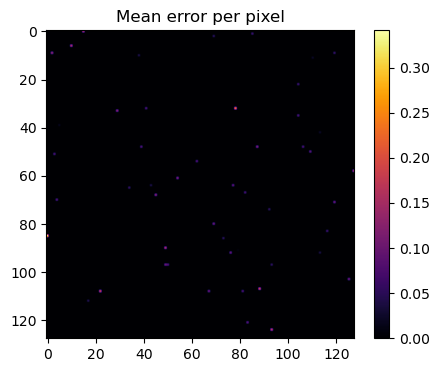

In [21]:
error_map = np.zeros(img.shape[:2])
count_map = np.zeros(img.shape[:2])

for (x, y), e in zip(positions, errors):
    error_map[x, y] += e
    count_map[x, y] += 1

error_map /= np.maximum(count_map, 1)

plt.figure(figsize=(5,4))
plt.imshow(error_map, cmap="inferno")
plt.title("Mean error per pixel")
plt.colorbar()
plt.show()

Load model once

In [22]:
def load_lama_model(model_path):
    with open(model_path / "config.yaml") as f:
        train_config = OmegaConf.create(yaml.safe_load(f))

    train_config.training_model.predict_only = True
    train_config.visualizer.kind = "noop"

    checkpoint_path = model_path / "models" / "best.ckpt"

    model = load_checkpoint(
        train_config,
        checkpoint_path,
        map_location="cpu",
        strict=False
    )

    model.freeze()
    return model


In [23]:
model_path = Path("/home/vishnu/git-test/lama/big-lama")
model = load_lama_model(model_path)

Predict using pre-loaded model

In [24]:
@torch.no_grad()
def predict_with_model(model, img, mask, pad_out_to_modulo=8):

    img = img.astype(np.float32)
    img_min, img_max = img.min(), img.max()
    img = (img - img_min) / (img_max - img_min)

    dset = {
        "image": np.transpose(img, (2,0,1)),
        "mask": mask[None, ...],
    }

    dset["unpad_to_size"] = dset["image"].shape[1:]
    dset["image"] = pad_img_to_modulo(dset["image"], pad_out_to_modulo)
    dset["mask"] = pad_img_to_modulo(dset["mask"], pad_out_to_modulo)

    batch = default_collate([dset])
    batch = move_to_device(batch, torch.device("cpu"))

    batch = model(batch)
    cur_res = batch["inpainted"].cpu().numpy()[0]

    h, w = dset["unpad_to_size"]
    cur_res = cur_res[:, :h, :w]

    cur_res = np.transpose(cur_res, (1,2,0))
    cur_res = (img_max - img_min) * cur_res + img_min

    return cur_res

### Single pixel masking 
Mask n pixels at random

In [25]:
def random_pixel_mask(img_shape, n, rng):
    H, W = img_shape[:2]
    mask = np.zeros((H, W), dtype=np.uint8)

    total = H * W
    n = min(n, total)

    idx = rng.choice(total, size=n, replace=False)
    xs = idx // W
    ys = idx % W

    mask[xs, ys] = 1
    return mask

In [26]:
def random_mask_experiment(
    model,
    img,
    n,
    n_samples,
    seed=0
):

    rng = np.random.default_rng(seed)
    errors = []

    for k in range(n_samples):
        mask = random_pixel_mask(img.shape, n, rng)
        
        pred = predict_with_model(model, img, mask)

        mse = np.mean((pred - img)**2)
        errors.append(mse)

        # if (k+1) % 1000 == 0:
        #     print(f"n={n}, sample {k+1}/{n_samples}")

    errors = np.array(errors)
    return errors.mean(), errors.var(), errors


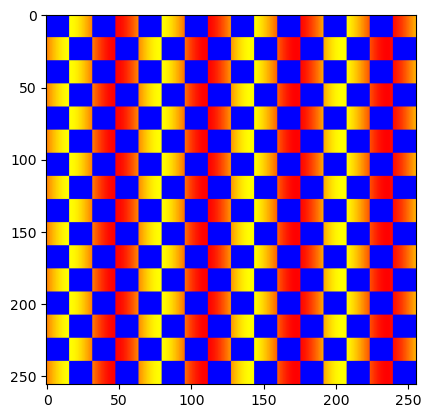

In [76]:
plt.imshow(img)

In [ ]:
H, W = 256, 256
n_max = H * W

K = 110  # number of mask sizes

# log separated
# n_values = np.unique(
#     np.round(
#         np.logspace(np.log10(1), np.log10(n_max), K)
#     ).astype(int)
# )

# Equally separated
# n_values = np.unique(
#     np.round(
#         np.linspace(1, n_max, K)
#     ).astype(int)
# )

# quadratically separated
n_values = np.unique(
    np.round(
        (np.linspace(0, 1, K)**2) * (n_max - 1) + 1
    ).astype(int)
)

seed=0
results = {
    "n_values": [],
    "mean_err": [],
    "var_err": [],
    "all_errors": {},
    "img_var": np.var(img),
    "image_shape": img.shape,
    "seed": seed
}

for n in n_values:

    m, v, errors = random_mask_experiment(
        model,
        img,
        n,
        n_samples=5000
    )

    results["n_values"].append(n)
    results["mean_err"].append(m)
    results["var_err"].append(v)
    results["all_errors"][n] = errors

    # SAVE CHECKPOINT
    np.savez(
        "lama_randMask_CheckerBoard.npz",
        **results
    )

    print(f"Saved results up to n = {n}")

Saved results up to n = 1
Saved results up to n = 7
Saved results up to n = 23
Saved results up to n = 51
Saved results up to n = 89
Saved results up to n = 139
Saved results up to n = 200
Saved results up to n = 271
Saved results up to n = 354
Saved results up to n = 448
Saved results up to n = 553
Saved results up to n = 668
Saved results up to n = 795
Saved results up to n = 933
Saved results up to n = 1082
Saved results up to n = 1242
Saved results up to n = 1413
Saved results up to n = 1595
Saved results up to n = 1788
Saved results up to n = 1992
Saved results up to n = 2207
Saved results up to n = 2434
Saved results up to n = 2671
Saved results up to n = 2919
Saved results up to n = 3178
Saved results up to n = 3448
Saved results up to n = 3730
Saved results up to n = 4022
Saved results up to n = 4326
Saved results up to n = 4640
Saved results up to n = 4965


In [ ]:
data64 = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_nat01.npz", allow_pickle=True)
n_values = data64["n_values"]
mean_err = data64["mean_err"]
var_err = data64["var_err"]
all_errors = data64["all_errors"].item()

df = pd.DataFrame({
    "n": n_values,
    "fraction": n_values / (128*128),
    "mean_mse": mean_err,
    "var_mse": var_err
})

In [ ]:
# data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_nat01.npz", allow_pickle=True)
data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_nat02.npz", allow_pickle=True)
# data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_CheckerBoard.npz", allow_pickle=True)
# data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_1.npz", allow_pickle=True)
# data = np.load("lama_CheckerBoard.npz", allow_pickle=True)

n_values = data["n_values"]
mean_err = data["mean_err"]
var_err = data["var_err"]
all_errors = data["all_errors"].item()

In [149]:
df = pd.DataFrame({
    "n": n_values,
    "fraction": n_values / (128*128),
    "mean_mse": mean_err,
    "var_mse": var_err
})

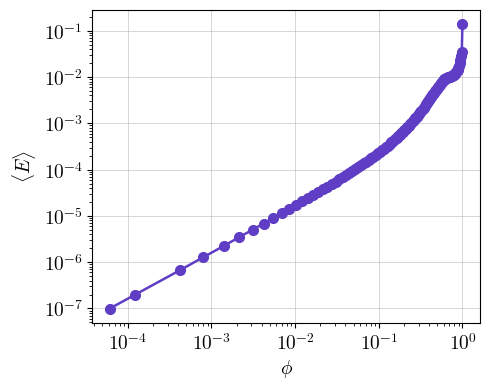

In [113]:
# Reset and apply style
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rc("font", family="Latin Modern Roman")
plt.rc("xtick", labelsize="medium")
plt.rc("ytick", labelsize="medium")
rc = {"mathtext.fontset": "cm"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = plt.rcParams["font.serif"]

# Use defined color
color_plot = colorsNw["violet"][9]

H, W = 128, 128
phi = df["n"] / (H * W)

# Plot
plt.figure(figsize=(5, 4))

plt.loglog(
    phi,
    df["mean_mse"],
    "-o",
    color=color_plot,
    markerfacecolor=color_plot,
    markeredgecolor=color_plot,
    linewidth=1.8,
    markersize=7,
)

ax = plt.gca()

ax.tick_params(axis="both", which="major", labelsize=14)

plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$\langle E \rangle$", fontsize=14)
plt.grid(True, which="major", linewidth=0.6, alpha=0.6)
# plt.grid(False, which="minor")

plt.tight_layout()
plt.show()

1.0002216068789047


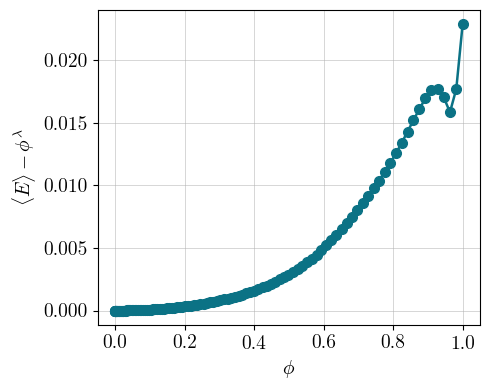

In [150]:
color_plot = colorsNw["cyan"][9]

# choose early region manually
mask = df["n"] < 150

x = np.log(df["n"][mask])
y = np.log(df["mean_mse"][mask])

lambda_fit = np.polyfit(x, y, 1)[0]
print(lambda_fit)

A = np.exp(np.polyfit(x, y, 1)[1]) # intercept -> Log(A)
scaled = df["mean_mse"] / (A * df["n"]**lambda_fit) - 1

plt.figure(figsize=(5,4))

plt.plot(
    phi,
    # df["mean_mse"] / (df["n"]**lambda_fit),
    # scaled,
    df["mean_mse"] - A * df["n"]**lambda_fit,
    "-o",
    color=color_plot,
    linewidth=1.8,
    markersize=7,
)

ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=14)

plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$\langle E \rangle - \phi^{\lambda}$", fontsize=14)

plt.grid(True, which="major", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

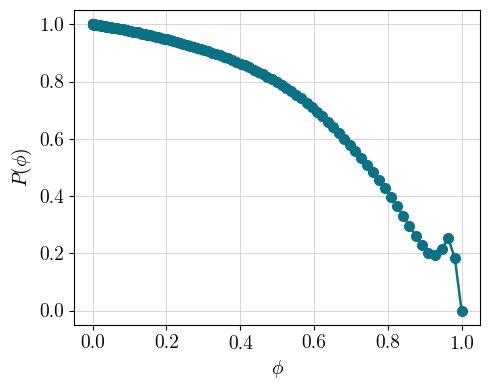

In [151]:
E = df["mean_mse"]

E_min = E.min()
E_max = E.max()
P = (E_max - E) / (E_max - E_min)
plt.figure(figsize=(5,4))

plt.plot(
    phi,
    P,
    "-o",
    color=color_plot,
    linewidth=1.8,
    markersize=7,
)

ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=14)

plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$P(\phi)$", fontsize=14)

plt.grid(True, which="major", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

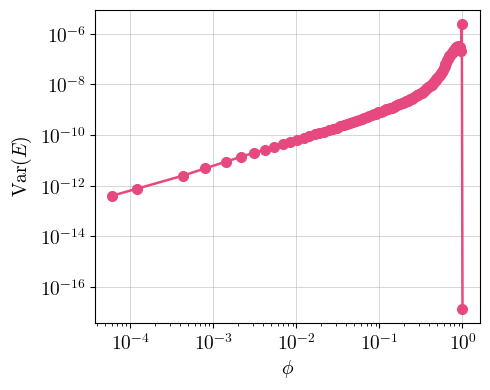

In [130]:
color_plot = colorsNw["pink"][6]

# Plot
plt.figure(figsize=(5, 4))

plt.loglog(
    phi,
    df["var_mse"],
    "-o",
    color=color_plot,
    markerfacecolor=color_plot,
    markeredgecolor=color_plot,
    linewidth=1.8,
    markersize=7,
)

ax = plt.gca()

# Tick size
ax.tick_params(axis="both", which="major", labelsize=14)

# Axis labels in proper math notation
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$\mathrm{Var}(E)$", fontsize=14)

# Major grid only
plt.grid(True, which="major", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

In [124]:
df["n"].iloc[1]

151

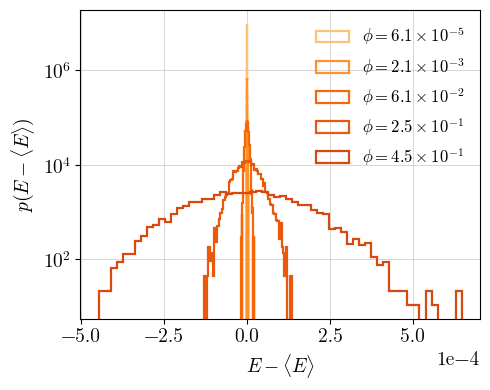

In [118]:
color_list = [
    colorsNw["orange"][3],
    colorsNw["orange"][5],
    colorsNw["orange"][7],
    colorsNw["orange"][8],
    colorsNw["orange"][9],
]

selected_n = [
    df["n"].iloc[0],
    df["n"].iloc[5],
    df["n"].iloc[len(df)//4],
    df["n"].iloc[len(df)//2],
    df["n"].iloc[round(len(df)/1.5)],
]

plt.figure(figsize=(5, 4))

for i, n in enumerate(selected_n):

    phi_val = n / (H * W)
    mantissa, exponent = f"{phi_val:.1e}".split("e")
    exponent = int(exponent)

    label = rf"$\phi = {mantissa}\times 10^{{{exponent}}}$"

    errs = all_errors[n]
    mean = np.mean(errs)

    errs_centered = errs - mean

    plt.hist(
        errs_centered,
        bins=60,
        density=True,
        histtype="step",
        linewidth=1.6,
        color=color_list[i],
        label=label
    )

ax = plt.gca()

# Tick styling
ax.tick_params(axis="both", which="major", labelsize=14)
# Scientific scaling on x-axis
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax.xaxis.get_offset_text().set_fontsize(14)

# Log scale
plt.yscale("log")

# Proper LaTeX labels
plt.xlabel(r"$E - \langle E \rangle$", fontsize=14)
plt.ylabel(r"$p(E - \langle E \rangle)$", fontsize=14)

# Major grid only
plt.grid(True, which="major", linewidth=0.6, alpha=0.6)

# Legend styling
plt.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

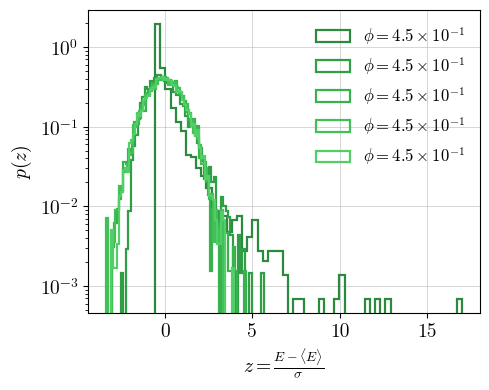

In [131]:
# Color sequence
color_list = [
    colorsNw["green"][9],
    colorsNw["green"][8],
    colorsNw["green"][7],
    colorsNw["green"][6],
    colorsNw["green"][5],
]

plt.figure(figsize=(5, 4))

for i, n in enumerate(selected_n):

    errs = all_errors[n]
    mean = np.mean(errs)
    sigma = np.std(errs)

    z = (errs - mean) / sigma

    plt.hist(
        z,
        bins=60,
        density=True,
        histtype="step",
        linewidth=1.6,
        color=color_list[i],
        label=label
    )

ax = plt.gca()

# Tick styling
ax.tick_params(axis="both", which="major", labelsize=14)

# Log scale
plt.yscale("log")

# Proper LaTeX labels (standardized variable)
plt.xlabel(r"$z=\frac{E - \langle E \rangle}{\sigma}$", fontsize=14)
plt.ylabel(r"$p(z)$", fontsize=14)

# Major grid only
plt.grid(True, which="major", linewidth=0.6, alpha=0.6)

# Legend styling
plt.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

In [59]:
h = [1]
for n in h:
    errs = np.sort(all_errors[n])
    print((len(errs)))


5000


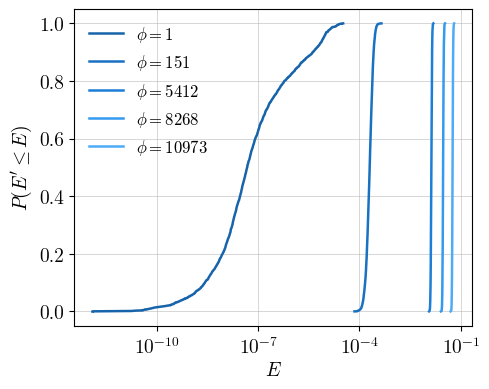

In [51]:
# Color sequence
color_list = [
    colorsNw["blue"][9],
    colorsNw["blue"][8],
    colorsNw["blue"][7],
    colorsNw["blue"][5],
    colorsNw["blue"][4],
]

plt.figure(figsize=(5, 4))

for i, n in enumerate(selected_n):

    errs = np.sort(all_errors[n])
    cdf = np.arange(len(errs)) / len(errs)

    plt.semilogx(
        errs,
        cdf,
        linewidth=1.8,
        color=color_list[i],
        label=rf"$\phi = {n}$"
    )

ax = plt.gca()

# Tick styling
ax.tick_params(axis="both", which="major", labelsize=14)

# Proper LaTeX labels (CDF uses uppercase P)
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$P(E' \leq E)$", fontsize=14)

# Major grid only
plt.grid(True, which="major", linewidth=0.6, alpha=0.6)

# Legend styling
plt.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

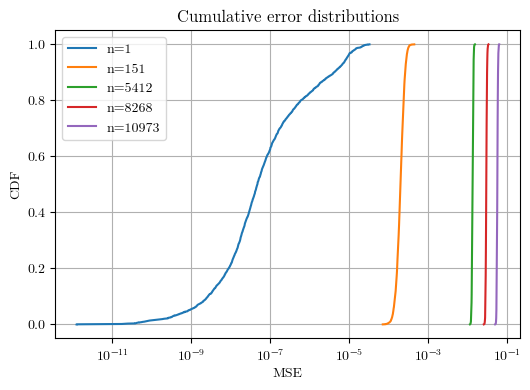

In [50]:
plt.figure(figsize=(6,4))

for n in selected_n:
    errs = np.sort(all_errors[n])
    cdf = np.arange(len(errs)) / len(errs)
    plt.semilogx(errs, cdf, label=f"n={n}")

plt.xlabel("MSE")
plt.ylabel("CDF")
plt.legend()
plt.title("Cumulative error distributions")
plt.grid()
plt.show()


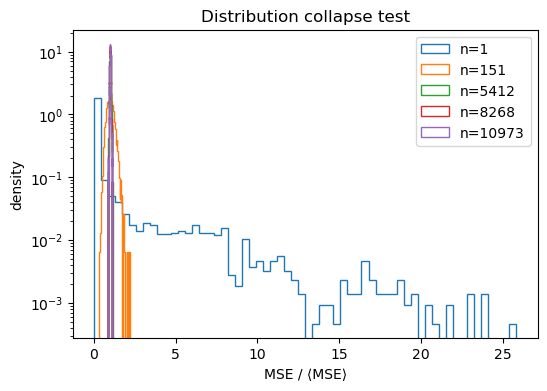

In [31]:
plt.figure(figsize=(6,4))

for n in selected_n:
    errs = all_errors[n] / df.loc[df["n"]==n, "mean_mse"].values[0]
    plt.hist(errs, bins=60, density=True, histtype="step", label=f"n={n}")

plt.yscale("log")
plt.xlabel("MSE / ⟨MSE⟩")
plt.ylabel("density")
plt.legend()
plt.title("Distribution collapse test")
plt.show()

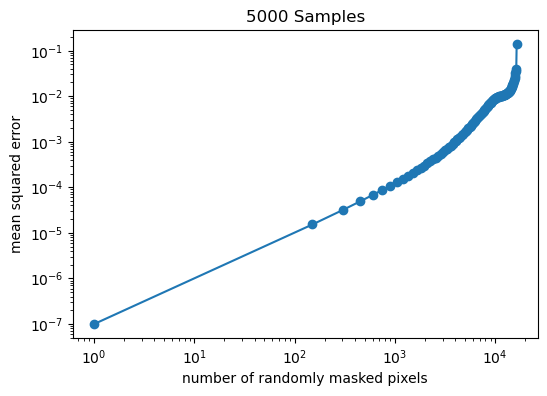

In [132]:
plt.figure(figsize=(6,4))
plt.loglog(n_values, mean_err, "-o")
plt.xlabel("number of randomly masked pixels")
plt.ylabel("mean squared error")
plt.title('5000 Samples')
plt.show()


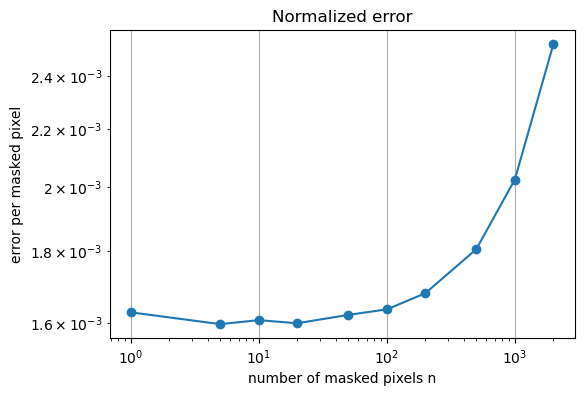

In [56]:
H, W, _ = img.shape
scaled_err = (H * W / np.array(n_values)) * np.array(mean_err)

sigma2 = np.var(img)
normalized_err = scaled_err / sigma2

plt.figure(figsize=(6,4))
plt.loglog(n_values, scaled_err, "-o")
plt.xlabel("number of masked pixels n")
plt.ylabel("error per masked pixel")
plt.title("Normalized error")
plt.grid()
plt.show()


In [ ]:
def mask_from_n_pixels(size, n, x0, y0):
    """
    Create compact mask of n pixels.
    Guaranteed termination.
    """

    H, W = size[:2]
    mask = np.zeros((H, W), dtype=np.uint8)

    # maximum possible pixels available
    max_pixels = (H - x0) * (W - y0)
    n = min(n, max_pixels)

    # approximate rectangle
    h = int(np.floor(np.sqrt(n)))
    w = int(np.ceil(n / h))

    count = 0

    for i in range(h):
        for j in range(w):
            if count >= n:
                break
            xi = x0 + i
            yj = y0 + j
            if xi < H and yj < W:
                mask[xi, yj] = 1
                count += 1
        if count >= n:
            break

    return mask


In [184]:
def mask_size_experiment(
    model,
    img,
    n_values,
    n_positions=10,
    seed=0
):

    rng = np.random.default_rng(seed)
    H, W, _ = img.shape

    mean_errors = []
    var_errors = []

    for n in n_values:
        errors = []

        for _ in range(n_positions):
            x0 = rng.integers(0, H)
            y0 = rng.integers(0, W)

            mask = mask_from_n_pixels(img.shape, n, x0, y0)

            pred = predict_with_model(model, img, mask)

            mse = np.mean((pred - img)**2)
            errors.append(mse)

        errors = np.array(errors)
        mean_errors.append(errors.mean())
        var_errors.append(errors.var())

        print(f"n={n:5d}  mean={errors.mean():.4e}")

    return np.array(mean_errors), np.array(var_errors)


In [211]:
# Choose number of pixel sizes: small number to start with

# n_values = np.arange(1, int(0.75*128*128), 5000)
# len(n_values)
n_values = [10,20]
n_values

[10, 20]

In [195]:
0.5*128*128

8192.0

In [212]:
mean_err, var_err = mask_size_experiment(
    model,
    img,
    n_values,
    n_positions=10
)

n=   10  mean=2.1139e-06
n=   20  mean=3.3274e-06


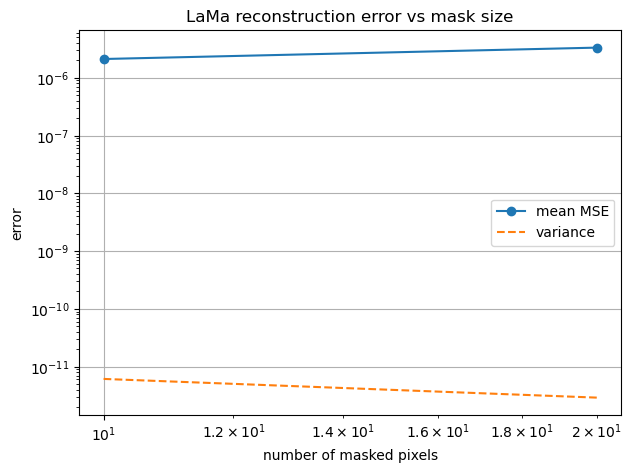

In [213]:
plt.figure(figsize=(7,5))
plt.loglog(n_values, mean_err, "-o", label="mean MSE")
plt.loglog(n_values, var_err, "--", label="variance")

plt.xlabel("number of masked pixels")
plt.ylabel("error")
plt.title("LaMa reconstruction error vs mask size")
plt.legend()
plt.grid()
plt.show()


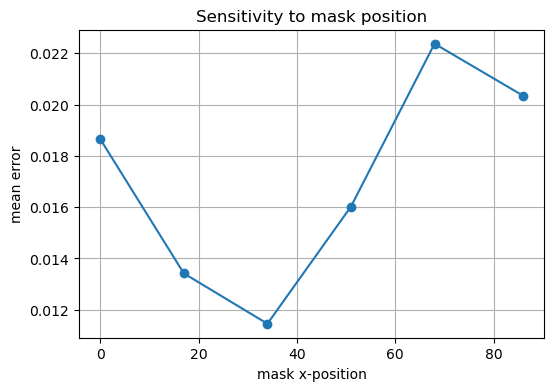

In [ ]:
H, W, _ = img.shape
wx, wy = H//3, W//3

xs = np.linspace(0, H-wx, 6).astype(int)
ys = W//3 * np.ones_like(xs).astype(int)

preds = []
errors = []

for x0, y0 in zip(xs, ys):
    mask = get_mask_shifted(img.shape, x0, y0, wx, wy)
    pred = predict(model_path, img, mask)

    err = np.linalg.norm(pred - img, axis=-1).mean()

    preds.append(pred)
    errors.append(err)

plt.figure(figsize=(6,4))
plt.plot(xs, errors, "-o")
plt.xlabel("mask x-position")
plt.ylabel("mean error")
plt.title("Sensitivity to mask position")
plt.grid()
plt.show()


In [43]:
def isotropic_spectrum(img):
    """
    img: (H, W) scalar field
    """
    H, W = img.shape
    fft = np.fft.fftshift(np.fft.fft2(img))
    psd = np.abs(fft)**2

    ky = np.fft.fftshift(np.fft.fftfreq(H))
    kx = np.fft.fftshift(np.fft.fftfreq(W))
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    k_bins = np.linspace(0, K.max(), min(H, W)//2)
    E = np.zeros(len(k_bins)-1)

    for i in range(len(E)):
        mask = (K >= k_bins[i]) & (K < k_bins[i+1])
        E[i] = psd[mask].mean()

    k_mid = 0.5*(k_bins[:-1] + k_bins[1:])
    return k_mid, E


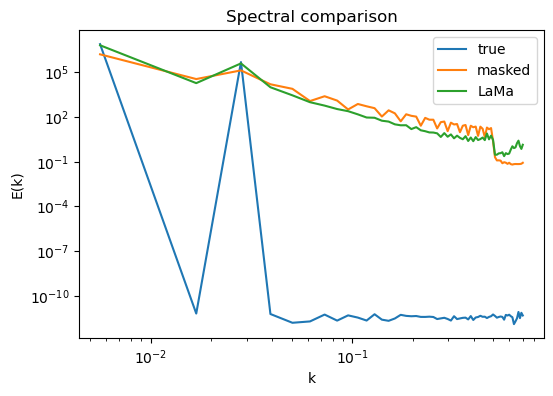

In [46]:
# pick one channel
u_true = img[:,:,0]
u_pred = pred[:,:,0]
u_masked = img[:,:,0] * mask

k, E_true = isotropic_spectrum(u_true)
_, E_pred = isotropic_spectrum(u_pred)
_, E_mask = isotropic_spectrum(u_masked)

plt.figure(figsize=(6,4))
plt.loglog(k, E_true, label="true")
plt.loglog(k, E_mask, label="masked")
plt.loglog(k, E_pred, label="LaMa")

plt.xlabel("k")
plt.ylabel("E(k)")
plt.legend()
plt.title("Spectral comparison")
plt.show()

In [63]:
def radial_correlation(field):
    field = field - field.mean()
    corr = np.fft.ifft2(np.abs(np.fft.fft2(field))**2).real
    corr = np.fft.fftshift(corr)

    H, W = field.shape
    y, x = np.indices((H, W))
    r = np.sqrt((x-W//2)**2 + (y-H//2)**2)

    r_bins = np.arange(0, min(H,W)//2)
    C = np.zeros(len(r_bins)-1)

    for i in range(len(C)):
        mask = (r >= r_bins[i]) & (r < r_bins[i+1])
        C[i] = corr[mask].mean()

    r_mid = 0.5*(r_bins[:-1] + r_bins[1:])
    return r_mid, C


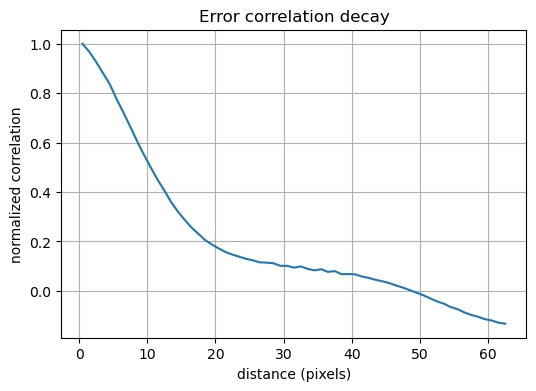

In [64]:
error = u_pred - u_true

r, C = radial_correlation(error)

plt.figure(figsize=(6,4))
plt.plot(r, C / C[0])
plt.xlabel("distance (pixels)")
plt.ylabel("normalized correlation")
plt.title("Error correlation decay")
plt.grid()
plt.show()


### Functional image 01 $-$ Universality check

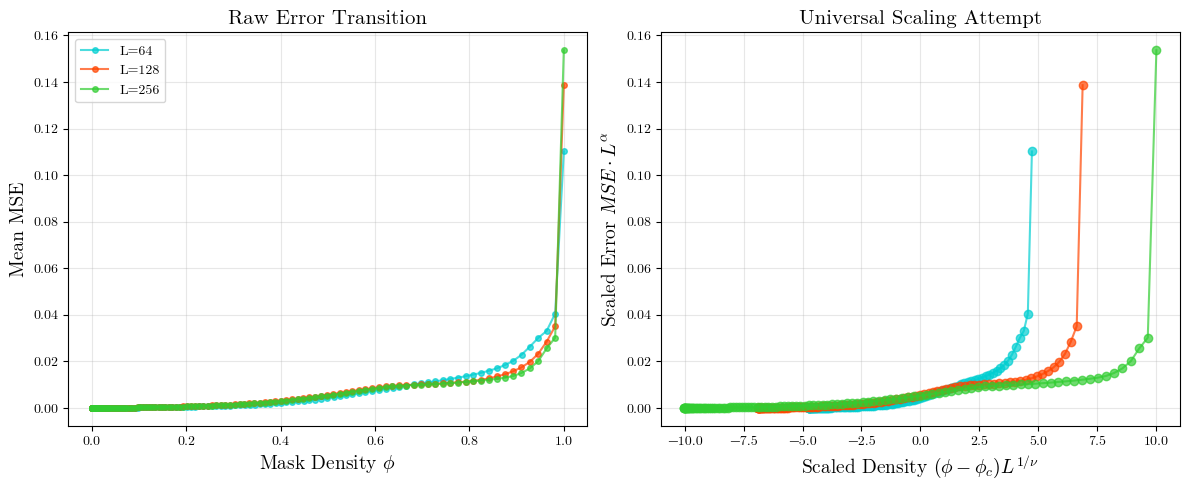

In [46]:
# --- Path Setup and Loading ---
base_path = "/home/vishnu/git-test/lama/Images/func1/"
sizes = [64, 128, 256]
files = {L: f"lama_randMask_{L}.npz" for L in sizes}

data_frames = {}

for L in sizes:
    data = np.load(os.path.join(base_path, files[L]), allow_pickle=True)
    n_values = data["n_values"]
    
    df = pd.DataFrame({
        "phi": n_values / (L * L),  # Normalized mask density
        "mean_mse": data["mean_err"],
        "var_mse": data["var_err"]
    })
    data_frames[L] = df

# --- Plotting Style (Your LaTeX Preference) ---
color_map = {64: "#00CED1", 128: "#FF4500", 256: "#32CD32"} # Cyan, Orange-Red, Lime-Green

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rc("font", family="Latin Modern Roman")
rc = {"mathtext.fontset": "cm"}
plt.rcParams.update(rc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot A: Raw Data (Phase Transition) ---
for L in sizes:
    df = data_frames[L]
    ax1.plot(df["phi"], df["mean_mse"], 'o-', label=f"L={L}", 
             markersize=4, color=color_map[L], alpha=0.7)

ax1.set_xlabel(r"Mask Density $\phi$", fontsize=14)
ax1.set_ylabel(r"Mean MSE", fontsize=14)
ax1.set_title("Raw Error Transition", fontsize=15)
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- Plot B: Data Collapse (The Scaling Search) ---
# ADJUST THESE: These are the knobs you turn to find the physics
phi_c = 0.5   # Guess for critical mask density
nu = 1.85     # Guess for 2D Percolation exponent
alpha = 0.0   # Guess for error scaling exponent (usually 0 if error is normalized)

for L in sizes:
    df = data_frames[L]
    # Scaling transformation:
    # x = (phi - phi_c) * L^(1/nu)
    # y = Mean_MSE * L^(alpha)
    scaled_x = (df["phi"] - phi_c) * (L ** (1/nu))
    scaled_y = df["mean_mse"] * (L ** alpha)
    
    ax2.plot(scaled_x, scaled_y, 'o-', color=color_map[L], label=f"L={L}", alpha=0.7)

ax2.set_xlabel(r"Scaled Density $(\phi - \phi_c) L^{1/\nu}$", fontsize=14)
ax2.set_ylabel(r"Scaled Error $MSE \cdot L^\alpha$", fontsize=14)
ax2.set_title("Universal Scaling Attempt", fontsize=15)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Block (k $\times$ k pixels) masking
Start with k=1 and reach the maximum area covered

In [ ]:
def random_block_mask(img_shape, n_target, k, rng):
    H, W = img_shape[:2]
    mask = np.zeros((H, W), dtype=np.uint8)
    
    # If target is the whole image, return all 1s
    if n_target >= H * W:
        return np.ones((H, W), dtype=np.uint8)
        
    # a) THE BOUNDARY PROBLEM: Define valid top-left coordinates
    valid_H = H - k + 1
    valid_W = W - k + 1
    total_valid = valid_H * valid_W
    
    # b) THE OVERLAP PROBLEM: Get a random permutation of all valid placements.
    # We draw without replacement from the list of valid corners.
    idx = rng.permutation(total_valid)
    xs = idx // valid_W
    ys = idx % valid_W
    
    # c) Drop blocks until we hit the target area
    for i in range(total_valid):
        r, c = xs[i], ys[i]
        mask[r:r+k, c:c+k] = 1
        
        # Stop as soon as the total masked area hits or exceeds target phi
        if mask.sum() >= n_target:
            break
            
    return mask

In [2]:
def block_mask_experiment(model, img, n_target, k, n_samples, seed=0):
    rng = np.random.default_rng(seed)
    errors = []
    actual_ns = [] # Track actual number of masked pixels
    
    for s in range(n_samples):
        mask = random_block_mask(img.shape, n_target, k, rng)
        
        # Assuming you have your predict function defined
        pred = predict_with_model(model, img, mask)
        
        mse = np.mean((pred - img)**2)
        errors.append(mse)
        actual_ns.append(mask.sum())
        
        # if (s+1) % 1000 == 0:
        #     print(f"n={n_target}, sample {s+1}/{n_samples}")
            
    errors = np.array(errors)
    actual_ns = np.array(actual_ns)
    
    # Return the actual mean phi achieved as well
    return errors.mean(), errors.var(), errors, actual_ns.mean()

In [ ]:
H, W = 128, 128
n_max = H * W
K_points = 110 # number of mask sizes
n_samples = 5000
seed = 0

# Quadratically separated targets
n_values_target = np.unique(
    np.round(
        (np.linspace(0, 1, K_points)**2) * (n_max - 1) + 1
    ).astype(int)
)

# 1. Define the blocks you want to test
k_values = [1, 2, 4, 8] 
image_name = "image_01" # Change this for each new image

# 2. Initialize the master results dictionary
results = {
    "n_values_target": n_values_target,
    "k_values": np.array(k_values),
    "img_var": np.var(img),
    "image_shape": np.array(img.shape),
    "seed": seed
}

# 3. Outer loop for block sizes
for k in k_values:
    print(f"\n=== Starting experiments for k = {k} ===")
    
    actual_ns = []
    mean_errs = []
    var_errs = []
    
    # Create a 2D array to hold all errors: Shape (110, 5000)
    # Better for .npz storage than a dictionary
    all_errs_matrix = np.zeros((len(n_values_target), n_samples)) 
    
    # Inner loop for mask densities
    for i, n in enumerate(n_values_target):
        m, v, errors, actual_n = block_mask_experiment(
            model, img, n, k=k, n_samples=n_samples, seed=seed
        )

        actual_ns.append(actual_n)
        mean_errs.append(m)
        var_errs.append(v)
        all_errs_matrix[i, :] = errors # Store the 5000 errors in the row

        # Optional: Print progress
        if i % 10 == 0 or i == len(n_values_target) - 1:
            print(f"  -> Processed target n = {n} (Actual phi ~ {actual_n:.1f})")
            
            # --- CONTINUOUS SAVING ---
            # Update the dictionary with current progress and save.
            # This overwrites the same file, keeping your folder clean,
            # but ensures you don't lose hours of data if the kernel dies.
            results[f"k{k}_n_actual"] = np.array(actual_ns)
            results[f"k{k}_mean_err"] = np.array(mean_errs)
            results[f"k{k}_var_err"] = np.array(var_errs)
            results[f"k{k}_all_errors"] = all_errs_matrix[:len(actual_ns), :] 
            
            np.savez(f"lama_results_{image_name}.npz", **results)

print(f"\nFinished! All data safely stored in 'lama_results_{image_name}.npz'")